In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("../data/document_data_clean_filtered.csv")

# 0) Specifications

In [3]:
palette_types = {
    'annuaire': (0.5803921568627451, 0.403921568627451, 0.7411764705882353),
    'presse généraliste': 'tab:orange',
    'presse spécialisée': 'tab:green',
    'presse officielle': 'tab:red',
    'monographie': 'tab:blue',
}

# 1) Person and Institutions

In [4]:
df["author_type_clean"].value_counts()

author_type_clean
entity    6734
person    3922
Name: count, dtype: int64

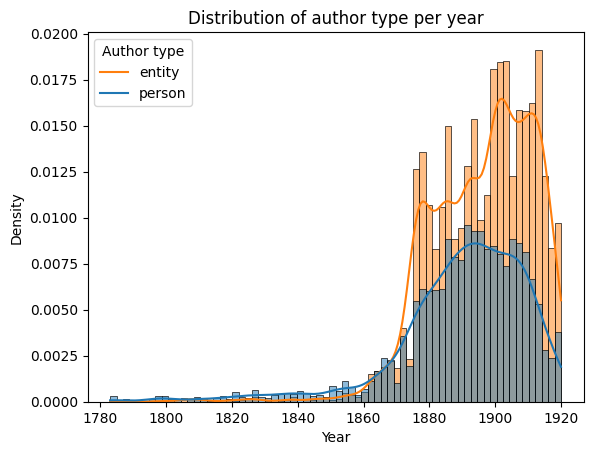

In [5]:
sns.histplot(df, x="date_clean", bins=70, hue="author_type_clean", kde=True, stat="density", label="Eucalyptus", alpha=0.5)
plt.title("Distribution of author type per year")
plt.xlabel("Year")
plt.legend(title='Author type', loc='upper left', labels=['entity', 'person'])

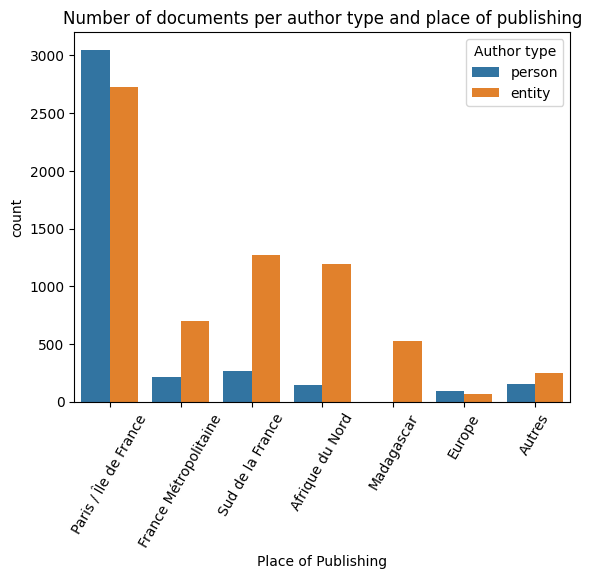

In [6]:
row_order = ["Paris / Île de France", "France Métropolitaine", "Sud de la France", "Afrique du Nord", "Madagascar", "Europe", "Autres"]
sns.countplot(data=df, x="publisher_place_country", hue="author_type_clean", order=row_order)
plt.xticks(rotation=60)
plt.title("Number of documents per author type and place of publishing")
plt.xlabel("Place of Publishing")
plt.legend(title='Author type', loc='upper right', labels=['person', 'entity'])
plt.show()

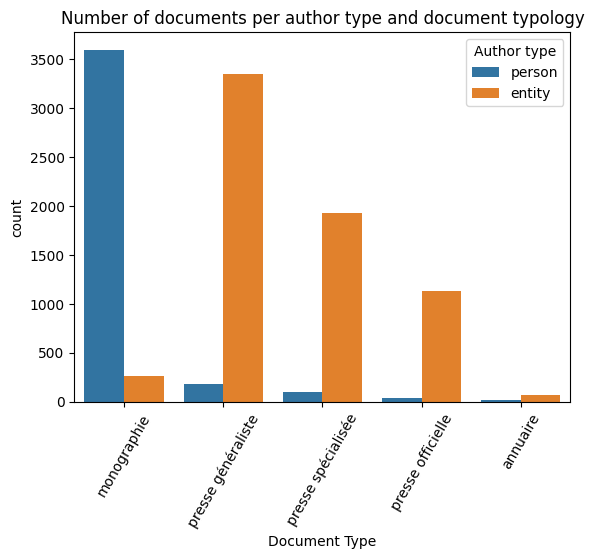

In [7]:
sns.countplot(data=df, x="type_clean", hue="author_type_clean")
plt.xticks(rotation=60)
plt.title("Number of documents per author type and document typology")
plt.xlabel("Document Type")
plt.legend(title='Author type', loc='upper right', labels=['person', 'entity'])
plt.show()

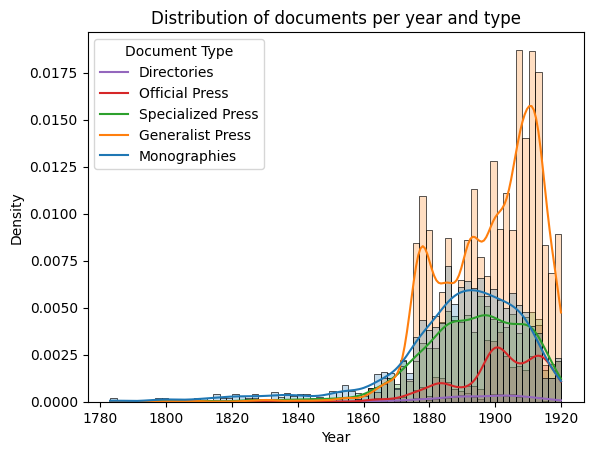

In [8]:
sns.histplot(df, x="date_clean", hue="type_clean", kde=True, bins=70, stat="density", label='Documents', palette=palette_types, alpha=0.25)
plt.title("Distribution of documents per year and type")
plt.xlabel("Year")
plt.legend(title='Document Type', loc='upper left', labels=['Directories', "Official Press", "Specialized Press", "Generalist Press", "Monographies"])
plt.show()

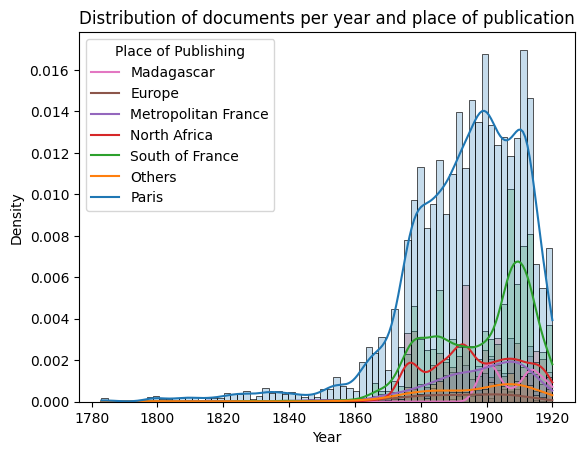

In [9]:
sns.histplot(df, x="date_clean", hue="publisher_place_country", kde=True, bins=70, stat="density", label='Documents', alpha=0.25)
plt.title("Distribution of documents per year and place of publication")
plt.xlabel("Year")
plt.legend(title='Place of Publishing', loc='upper left', labels=['Madagascar', "Europe", "Metropolitan France", "North Africa", "South of France", "Others", "Paris"])
plt.show()

In [10]:
df_officielle = df[df["type_clean"] == "presse officielle"]
df_officielle[df_officielle["date_clean"] > 1897]["publisher_place_country"].value_counts(normalize=True)

publisher_place_country
Madagascar               0.491870
Paris / Île de France    0.258130
Autres                   0.089431
Afrique du Nord          0.088415
Sud de la France         0.050813
France Métropolitaine    0.020325
Europe                   0.001016
Name: proportion, dtype: float64

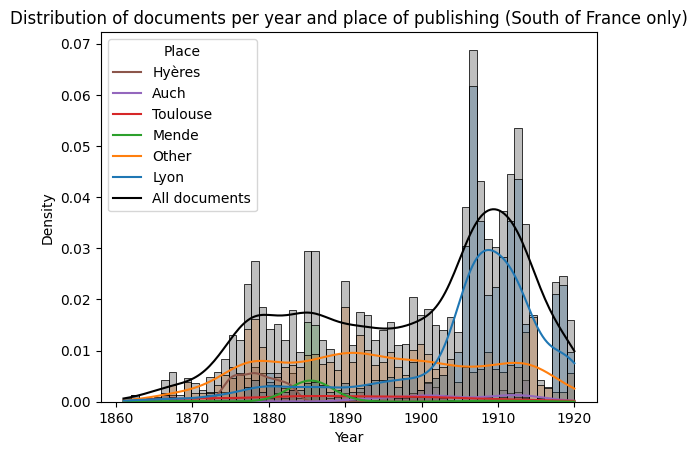

In [11]:
df_south = df[df["publisher_place_country"] == "Sud de la France"]
df_south = df_south[df_south["date_clean"] > 1860]
def place_test(place):
    if place in ["Lyon", "Mende", "Toulouse", "Hyères", "Auch"]:
        return place
    else:
        return "Other"
df_south["place_test"] = df_south["publisher_place_clean"].map(place_test)
bins = int(1920-1860)

sns.histplot(df_south, x="date_clean", hue="place_test", kde=True, bins=bins, stat="density", alpha=0.25)
sns.histplot(df_south, x="date_clean", kde=True, bins=bins, stat="density", color="black", alpha=0.25)

plt.title("Distribution of documents per year and place of publishing (South of France only)")
plt.xlabel("Year")
plt.legend(title='Place', loc='upper left', labels=["Hyères", "Auch", "Toulouse", "Mende", "Other", "Lyon", "All documents"])
plt.show()

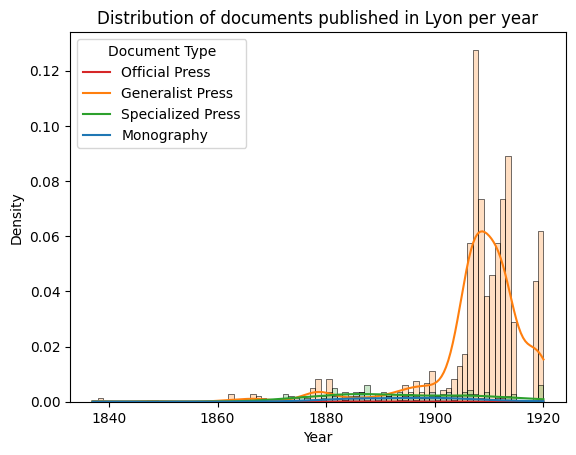

In [12]:
bins = int(df[df["publisher_place_clean"] == "Lyon"]["date_clean"].max() - df[df["publisher_place_clean"] == "Lyon"]["date_clean"].min())

sns.histplot(df[df["publisher_place_clean"] == "Lyon"], x="date_clean", hue="type_clean", kde=True, bins=bins, stat="density", palette=palette_types, alpha=0.25)
plt.title("Distribution of documents published in Lyon per year")
plt.legend(title='Document Type', loc='upper left', labels=["Official Press", "Generalist Press", "Specialized Press", "Monography"])
plt.xlabel("Year")
plt.show()

In [13]:
df["occurences_ratio"].mean()

np.float64(0.010299254376358999)

In [14]:
df[df["type_clean"] == "presse généraliste"]["occurences_ratio"].mean()

np.float64(0.01058722774788926)

In [15]:
df_lyon = df[df["publisher_place_clean"] == "Lyon"]
df_lyon[df_lyon["type_clean"] == "presse généraliste"]["occurences_ratio"].describe()

count    1228.000000
mean        0.005130
std         0.005190
min         0.000189
25%         0.002677
50%         0.003830
75%         0.005547
max         0.089912
Name: occurences_ratio, dtype: float64

In [ ]:
df_lyon["title_clean"].value_counts()

KeyError: 'titre_clean'